In [1]:
# no knowlege and prior knowlege
# raw vs modeled probability of noise complaints with reason compared to other mean days in the week

import warnings

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
)

In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
from helpers import prep_the_data
import matplotlib.pyplot as plt
from helpers import ( prep_the_data, plot_panel_mu_by_weekday)

### Load + prepare data: 2021-2024 

In [3]:
df_puma = pd.read_parquet(
    "../data/processed/features/puma_noise_counts.parquet"
)


In [4]:
df_puma = prep_the_data(df_puma)

In [5]:
df_puma_2021__2024 = df_puma.loc[
    (df_puma["created_bucket"] >= "2021-01-01") &
    (df_puma["created_bucket"] <  "2024-12-31")
].copy()

In [6]:

# categorical key
keys = df_puma_2021__2024["dow_complaint"].astype(str)  # or dow_complaint if you didn't collapse
codes, dow_complaint_idx = np.unique(keys, return_inverse=True)

# Step 1: daily totals per category × weekday × date
daily = (
    df_puma_2021__2024
    .groupby(["dow_complaint", "created_bucket"], as_index=False)["complaint_count"]
    .sum()
)

# Step 2: average across days
agg_city = (
    daily
    .groupby("dow_complaint", as_index=False)["complaint_count"]
    .mean()
    .rename(columns={"complaint_count": "avg_daily_count"})
    .sort_values("dow_complaint")
    .reset_index(drop=True)
)

# coords = {"dow_complaint": agg_city["dow_complaint"].astype(str).tolist()}



In [7]:
coords = {"dow_complaint": agg_city["dow_complaint"].astype(str).tolist()}

y = agg_city["avg_daily_count"].to_numpy().astype("float32")

In [8]:
with pm.Model(coords=coords) as model_pois_1:
    log_mu = pm.Normal("log_mu", 0, 2, dims="dow_complaint")
    mu = pm.Deterministic("mu", pm.math.exp(log_mu), dims="dow_complaint")

    y_obs = pm.Poisson("y_obs", mu=mu, observed=y)

    idata_pois_1 = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log_mu]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 27 seconds.


In [9]:
az.summary(idata_pois_1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
log_mu[ANIMAL__Friday],2.478,0.284,1.955,2.987,0.004,0.005,5957.0,2994.0,1.0
log_mu[ANIMAL__Monday],2.556,0.276,2.022,3.045,0.004,0.004,6283.0,3334.0,1.0
log_mu[ANIMAL__Saturday],2.385,0.313,1.765,2.955,0.004,0.006,6801.0,2878.0,1.0
log_mu[ANIMAL__Sunday],2.475,0.280,1.948,2.992,0.004,0.005,6078.0,3113.0,1.0
log_mu[ANIMAL__Thursday],2.758,0.253,2.311,3.250,0.003,0.004,6207.0,3164.0,1.0
...,...,...,...,...,...,...,...,...,...
mu[SOCIAL_PARTY__Saturday],2444.569,50.009,2356.994,2543.653,0.666,0.803,5602.0,3212.0,1.0
mu[SOCIAL_PARTY__Sunday],2769.409,54.237,2671.124,2873.770,0.695,0.931,6105.0,2856.0,1.0
mu[SOCIAL_PARTY__Thursday],929.544,31.571,869.546,988.062,0.404,0.504,6085.0,2886.0,1.0
mu[SOCIAL_PARTY__Tuesday],925.735,30.542,868.450,983.230,0.397,0.504,5948.0,3046.0,1.0


In [10]:
with model_pois_1:
    ppc_pois_1 = pm.sample_posterior_predictive(
        idata_pois_1,
        var_names=["y_obs"],
        random_seed=42
    )

Sampling: [y_obs]


Output()

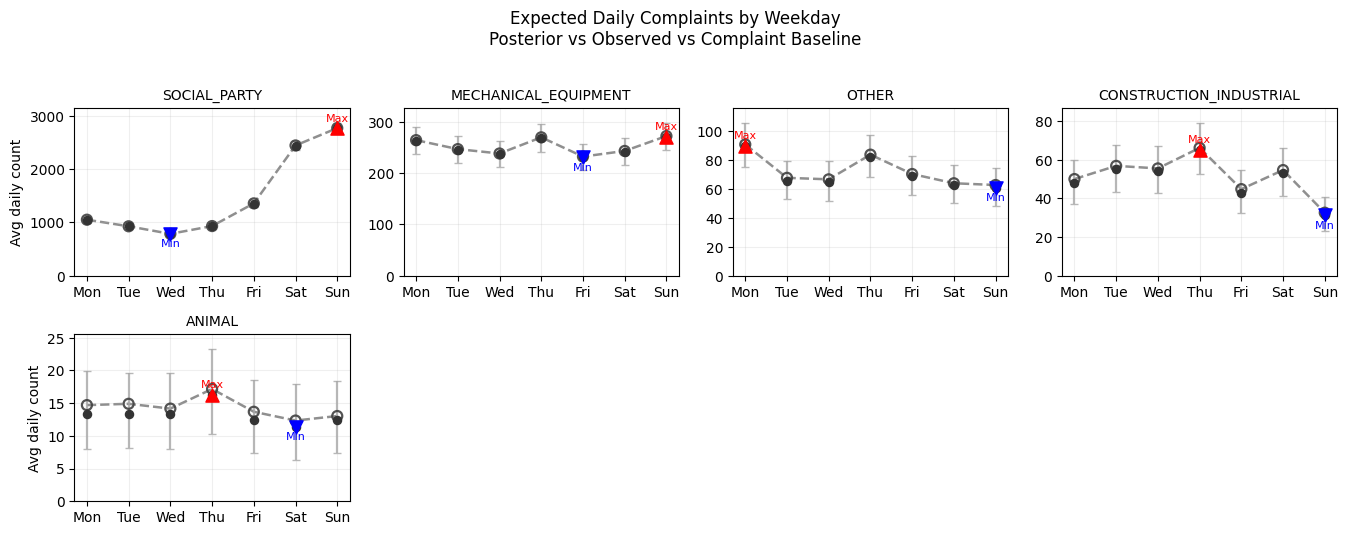

In [11]:
plot_panel_mu_by_weekday(
    idata_pois_1,
    agg_city=agg_city,
    top_n=None,   # or 5
    ncols=4,
    show_observed=True,
)